# EDA TRT4 - Análise do resultado dos WebScraping

## Imports

In [1]:
!pip install pandas matplotlib requests json re csv matplotlib-venn
!pip install matplotlib
!pip install seaborn
!pip install plotly seaborn
!pip install rapidfuzz 

ERROR: Could not find a version that satisfies the requirement json (from versions: none)
ERROR: No matching distribution found for json


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
import re
import unicodedata
from difflib import SequenceMatcher
from collections import Counter
from rapidfuzz import fuzz


In [3]:
def normalizar_nome_parte(nome):
    if pd.isna(nome):
        return nome

    texto = str(nome).strip().upper()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(char for char in texto if not unicodedata.combining(char))
    texto = re.sub(r'[^A-Z0-9\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def similarity_score(a, b, method='token_sort_ratio'):
    """
    Retorna score 0-100 de similaridade entre `a` e `b`.
    method: 'token_sort_ratio' | 'token_set_ratio' | 'ratio'
    """
    if a is None or b is None:
        return 0
    a, b = str(a).strip(), str(b).strip()
    if not a or not b:
        return 0
    if method == 'token_set_ratio':
        return fuzz.token_set_ratio(a, b)
    if method == 'ratio':
        return fuzz.ratio(a, b)
    return fuzz.token_sort_ratio(a, b)


def canonicalize_names(names, threshold=95, prefix_len=3, scorer=fuzz.token_sort_ratio):
    """
    Gera um mapping {nome: canonical} usando rapidfuzz.
    - names: iterável de strings (ex: series.unique() ou lista de nomes)
    - threshold: 0-100 (ex: 95)
    - prefix_len: blocking por prefixo para reduzir comparações
    - scorer: função de comparação do rapidfuzz (padrão token_sort_ratio)
    Retorna: dict mapping {nome_unico: nome_canonical}
    """
    counts = Counter([n for n in names if n and str(n).strip() != ''])
    uniques = list(counts.keys())

    # blocking simples por prefixo
    buckets = {}
    for n in uniques:
        key = n[:prefix_len] if len(n) >= prefix_len else n
        buckets.setdefault(key, []).append(n)

    mapping = {}
    for bucket in buckets.values():
        # representantes mais frequentes primeiro
        bucket.sort(key=lambda x: -counts.get(x, 0))
        for i, a in enumerate(bucket):
            if a in mapping:
                continue
            mapping[a] = a
            for b in bucket[i+1:]:
                if b in mapping:
                    continue
                score = scorer(a, b)
                if score >= threshold:
                    mapping[b] = mapping[a]

    return mapping


def apply_mapping_to_series(series, mapping):
    """Aplica o mapping a uma Series pandas (retorna Series com valores canônicos)."""
    return series.map(mapping).fillna(series)


def plot_top_values(df, column, title, ax, top_n=15):
    counts = df[column].dropna().astype(str).value_counts().head(top_n)
    colors = sns.color_palette('viridis', len(counts))
    ax.barh(counts.index, counts.values, color=colors)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Quantidade de ocorrências')
    ax.set_ylabel(column.capitalize())
    return counts


def resumo_eda_advogados(df, nome_dataset):
    print(f'\nResumo - {nome_dataset}')
    print(f'Advogados únicos: {df["nome"].nunique(dropna=True)}')
    if 'nome_canon' in df.columns:
        print(f'Advogados únicos após canonicalização: {df["nome_canon"].nunique(dropna=True)}')
    elif 'nome_normalizado' in df.columns:
        print(f'Advogados únicos após normalização: {df["nome_normalizado"].nunique(dropna=True)}')
    print(f'OABs únicos: {df["oab"].nunique(dropna=True)}')
    print('\nTop 10 advogados mais comuns:')
    display(df['nome'].value_counts().head(10).to_frame('quantidade'))
    if 'nome_canon' in df.columns:
        print('\nTop 10 advogados mais comuns após canonicalização:')
        display(df['nome_canon'].value_counts().head(10).to_frame('quantidade'))
    elif 'nome_normalizado' in df.columns:
        print('\nTop 10 advogados mais comuns após normalização:')
        display(df['nome_normalizado'].value_counts().head(10).to_frame('quantidade'))
    print('\nTop 10 OABs mais comuns:')
    display(df['oab'].value_counts().head(10).to_frame('quantidade'))

    if 'nome_canon' in df.columns:
        coluna_nome = 'nome_canon'
        titulo_nome = 'Top 15 advogados (canonicalizados)'
    else:
        coluna_nome = 'nome_normalizado' if 'nome_normalizado' in df.columns else 'nome'
        titulo_nome = 'Top 15 advogados normalizados' if coluna_nome == 'nome_normalizado' else 'Top 15 advogados'
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    plot_top_values(df, coluna_nome, f'{titulo_nome} - {nome_dataset}', axes[0])
    plot_top_values(df, 'oab', f'Top 15 OABs - {nome_dataset}', axes[1])
    plt.tight_layout()
    plt.show()


def resumo_eda_passivo(df, nome_dataset):
    print(f'\nResumo - {nome_dataset}')
    print(f'Partes únicas no polo passivo: {df["nome"].nunique(dropna=True)}')
    if 'nome_canon' in df.columns:
        print(f'Partes únicas no polo passivo após canonicalização: {df["nome_canon"].nunique(dropna=True)}')
    elif 'nome_normalizado' in df.columns:
        print(f'Partes únicas no polo passivo após normalização: {df["nome_normalizado"].nunique(dropna=True)}')
    print('\nTop 10 polos passivos mais comuns:')
    display(df['nome'].value_counts().head(10).to_frame('quantidade'))
    if 'nome_canon' in df.columns:
        print('\nTop 10 polos passivos mais comuns após canonicalização:')
        display(df['nome_canon'].value_counts().head(10).to_frame('quantidade'))
    elif 'nome_normalizado' in df.columns:
        print('\nTop 10 polos passivos mais comuns após normalização:')
        display(df['nome_normalizado'].value_counts().head(10).to_frame('quantidade'))

    if 'nome_canon' in df.columns:
        coluna_nome = 'nome_canon'
        titulo_nome = 'Top 15 polos passivos (canonicalizados)'
    else:
        coluna_nome = 'nome_normalizado' if 'nome_normalizado' in df.columns else 'nome'
        titulo_nome = 'Top 15 polos passivos normalizados' if coluna_nome == 'nome_normalizado' else 'Top 15 polos passivos'
    fig, axes = plt.subplots(1, 1, figsize=(18, 7))
    plot_top_values(df, coluna_nome, f'{titulo_nome} - {nome_dataset}', axes)
    plt.tight_layout()
    plt.show()


def resumo_eda_ativo(df, nome_dataset):
    print(f'\nResumo - {nome_dataset}')
    print(f'Partes únicas no polo ativo: {df["nome"].nunique(dropna=True)}')
    if 'nome_canon' in df.columns:
        print(f'Partes únicas no polo ativo após canonicalização: {df["nome_canon"].nunique(dropna=True)}')
    elif 'nome_normalizado' in df.columns:
        print(f'Partes únicas no polo ativo após normalização: {df["nome_normalizado"].nunique(dropna=True)}')
    print('\nTop 10 polos ativos mais comuns:')
    display(df['nome'].value_counts().head(10).to_frame('quantidade'))
    if 'nome_canon' in df.columns:
        print('\nTop 10 polos ativos mais comuns após canonicalização:')
        display(df['nome_canon'].value_counts().head(10).to_frame('quantidade'))
    elif 'nome_normalizado' in df.columns:
        print('\nTop 10 polos ativos mais comuns após normalização:')
        display(df['nome_normalizado'].value_counts().head(10).to_frame('quantidade'))

    if 'nome_canon' in df.columns:
        coluna_nome = 'nome_canon'
        titulo_nome = 'Top 15 polos ativos (canonicalizados)'
    else:
        coluna_nome = 'nome_normalizado' if 'nome_normalizado' in df.columns else 'nome'
        titulo_nome = 'Top 15 polos ativos normalizados' if coluna_nome == 'nome_normalizado' else 'Top 15 polos ativos'
    fig, axes = plt.subplots(1, 1, figsize=(18, 7))
    plot_top_values(df, coluna_nome, f'{titulo_nome} - {nome_dataset}', axes)
    plt.tight_layout()
    plt.show()

## Definir DF

In [4]:
df_ord = pd.read_csv('/Users/Marcella/pesquisa_insper_luciana/trt4_similariedade/data/webscraping/trt4_rito_ord/df_trt4_rito_ord.csv')
df_sum = pd.read_csv('/Users/Marcella/pesquisa_insper_luciana/trt4_similariedade/data/webscraping/trt4_rito_sumarissimo/df_trt4_rito_sum.csv')

In [5]:
df_ord_sem_nome = df_ord[df_ord['nome'].isna()].copy()
df_ord_sem_nome = df_ord_sem_nome.drop_duplicates(subset=['numero_processo'])
df_sum_sem_nome = df_sum[df_sum['nome'].isna()].copy()
df_sum_sem_nome = df_sum_sem_nome.drop_duplicates(subset=['numero_processo'])

print(f'Rito ordinário - casos sem nome: {len(df_ord_sem_nome)}')
print(f'Rito sumário - casos sem nome: {len(df_sum_sem_nome)}')
total_preenchidos_ord = len(df_ord) - len(df_ord_sem_nome)
total_preenchidos_sum = len(df_sum) - len(df_sum_sem_nome)
print(f'Rito ordinário ({len(df_ord)})- casos com nome preenchido: {total_preenchidos_ord} ({total_preenchidos_ord/len(df_ord)*100:.2f}%)')
print(f'Rito sumário ({len(df_sum)}) - casos com nome preenchido: {total_preenchidos_sum} ({total_preenchidos_sum/len(df_sum)*100:.2f}%)')

Rito ordinário - casos sem nome: 11905
Rito sumário - casos sem nome: 5072
Rito ordinário (266321)- casos com nome preenchido: 254416 (95.53%)
Rito sumário (70684) - casos com nome preenchido: 65612 (92.82%)


In [6]:
#deixando só os processos que TEM nome preenchido
df_ord = df_ord[df_ord['nome'].notna()].copy()
print(df_ord.shape)
df_sum = df_sum[df_sum['nome'].notna()].copy()
print(df_sum.shape)

(254416, 6)
(65612, 6)


In [7]:
df_ord['nome_normalizado'] = df_ord['nome'].apply(normalizar_nome_parte)
df_sum['nome_normalizado'] = df_sum['nome'].apply(normalizar_nome_parte)

In [8]:
nomes_ord = df_ord['nome_normalizado'].dropna().unique()
mapping_ord = canonicalize_names(nomes_ord, threshold=95, prefix_len=3)
df_ord['nome_canon'] = df_ord['nome_normalizado'].map(mapping_ord).fillna(df_ord['nome_normalizado'])

nomes_sum = df_sum['nome_normalizado'].dropna().unique()
mapping_sum = canonicalize_names(nomes_sum, threshold=95, prefix_len=3)
df_sum['nome_canon'] = df_sum['nome_normalizado'].map(mapping_sum).fillna(df_sum['nome_normalizado'])

## Quantidades

In [9]:
print('valores únicos de processo ordinários: ', df_ord['numero_processo'].nunique())
print('valores únicos de processo sumário: ', df_sum['numero_processo'].nunique())

valores únicos de processo ordinários:  45361
valores únicos de processo sumário:  13749


## EDA - Advogados

In [10]:
df_ord_adv = df_ord[df_ord['registro_tipo'] == 'advogado'].copy()
df_sum_adv = df_sum[df_sum['registro_tipo'] == 'advogado'].copy()


Resumo - Rito ordinário
Advogados únicos: 15968
Advogados únicos após canonicalização: 15937
OABs únicos: 16001

Top 10 advogados mais comuns:


,quantidade
nome,
RENATA PEREIRA ZANARDI,1276
DENISE PIRES FINCATO,909
LUCIANO BAUER WIENKE,797
IBOTI OLIVEIRA BARCELOS JUNIOR,673
MARCELO VIEIRA PAPALEO,651
ANGELA MARIA RAFFAINER FLORES,633
FERNANDA VIDAL PEREIRA FONTANA,618
GUILHERME GUIMARAES,605
HENRIQUE CUSINATO HERMANN,598



Top 10 advogados mais comuns após canonicalização:


,quantidade
nome_canon,
RENATA PEREIRA ZANARDI,1276
DENISE PIRES FINCATO,909
LUCIANO BAUER WIENKE,797
IBOTI OLIVEIRA BARCELOS JUNIOR,673
MARCELO VIEIRA PAPALEO,651
ANGELA MARIA RAFFAINER FLORES,633
FERNANDA VIDAL PEREIRA FONTANA,618
GUILHERME GUIMARAES,605
HENRIQUE CUSINATO HERMANN,598



Top 10 OABs mais comuns:


,quantidade
oab,
RS-33819,1276
RS-37057,910
RS-67897,797
RS-65382,673
RS-62546,651
RS-67060,618
RS-37672,605
RS-26977,599
RS-46523,594


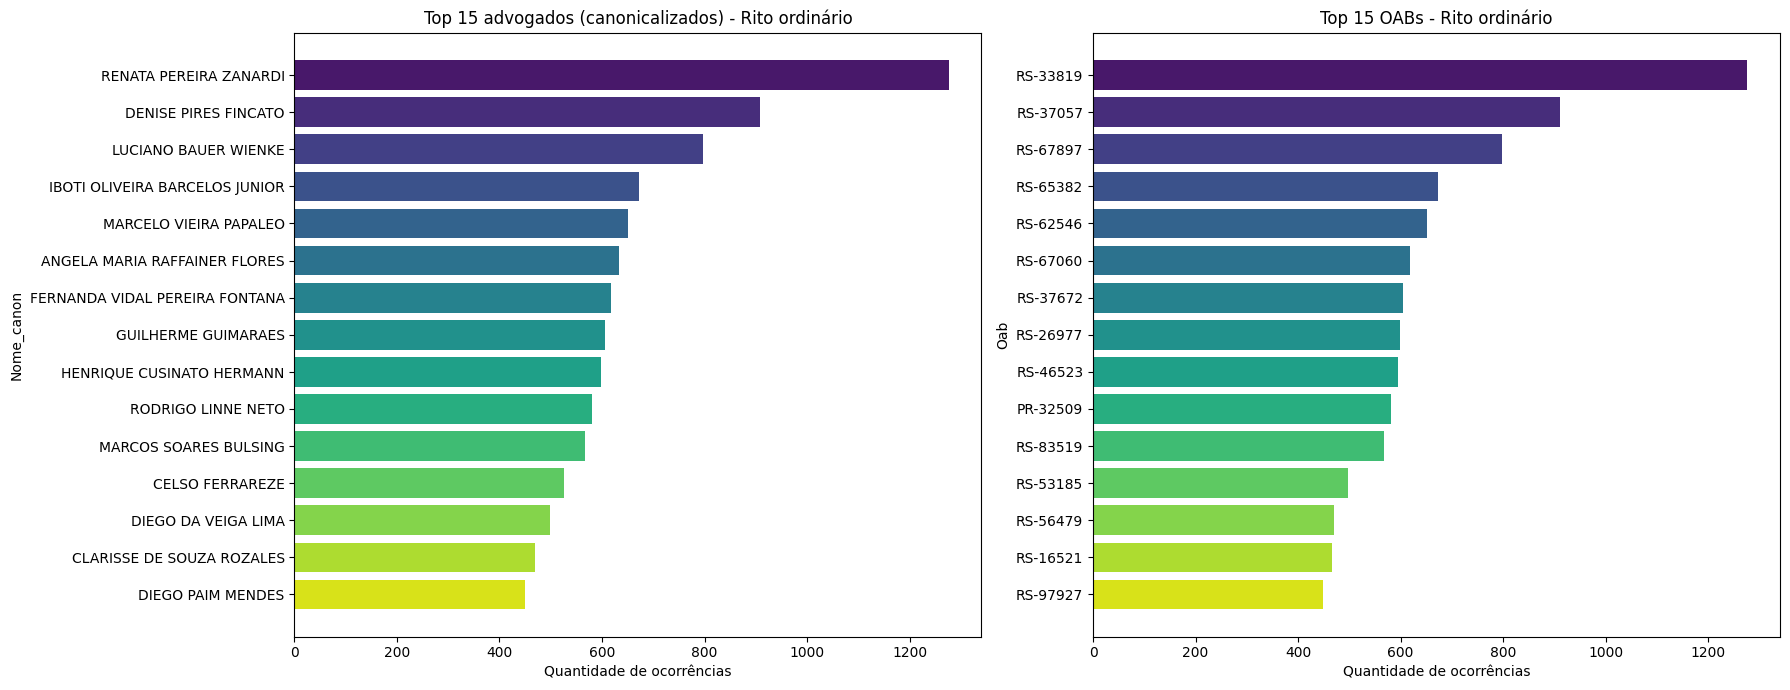


Resumo - Rito sumaríssimo
Advogados únicos: 9326
Advogados únicos após canonicalização: 9314
OABs únicos: 9356

Top 10 advogados mais comuns:


,quantidade
nome,
RODRIGO OLIVEIRA DA COSTA,521
RENATA PEREIRA ZANARDI,333
DANIEL FLORES SACCOL,235
BERATAN LUIZ FRANDALOSO,227
DENISE PIRES FINCATO,194
ANDRIO PORTUGUEZ FONSECA,182
RAFAEL DIAS DO CANTO,180
ROGERIO APARECIDO FERNANDES DE CARVALHO,173
PAULO FERNANDO LORENCO,168



Top 10 advogados mais comuns após canonicalização:


,quantidade
nome_canon,
RODRIGO OLIVEIRA DA COSTA,521
RENATA PEREIRA ZANARDI,333
DANIEL FLORES SACCOL,235
BERATAN LUIZ FRANDALOSO,227
DENISE PIRES FINCATO,194
ANDRIO PORTUGUEZ FONSECA,182
RAFAEL DIAS DO CANTO,180
ROGERIO APARECIDO FERNANDES DE CARVALHO,173
PAULO FERNANDO LORENCO,168



Top 10 OABs mais comuns:


,quantidade
oab,
RS-81290,521
RS-33819,333
RS-87044,235
RS-28349,227
RS-37057,194
RS-31913,182
RS-76095,180
RS-49578,173
RS-93122,168


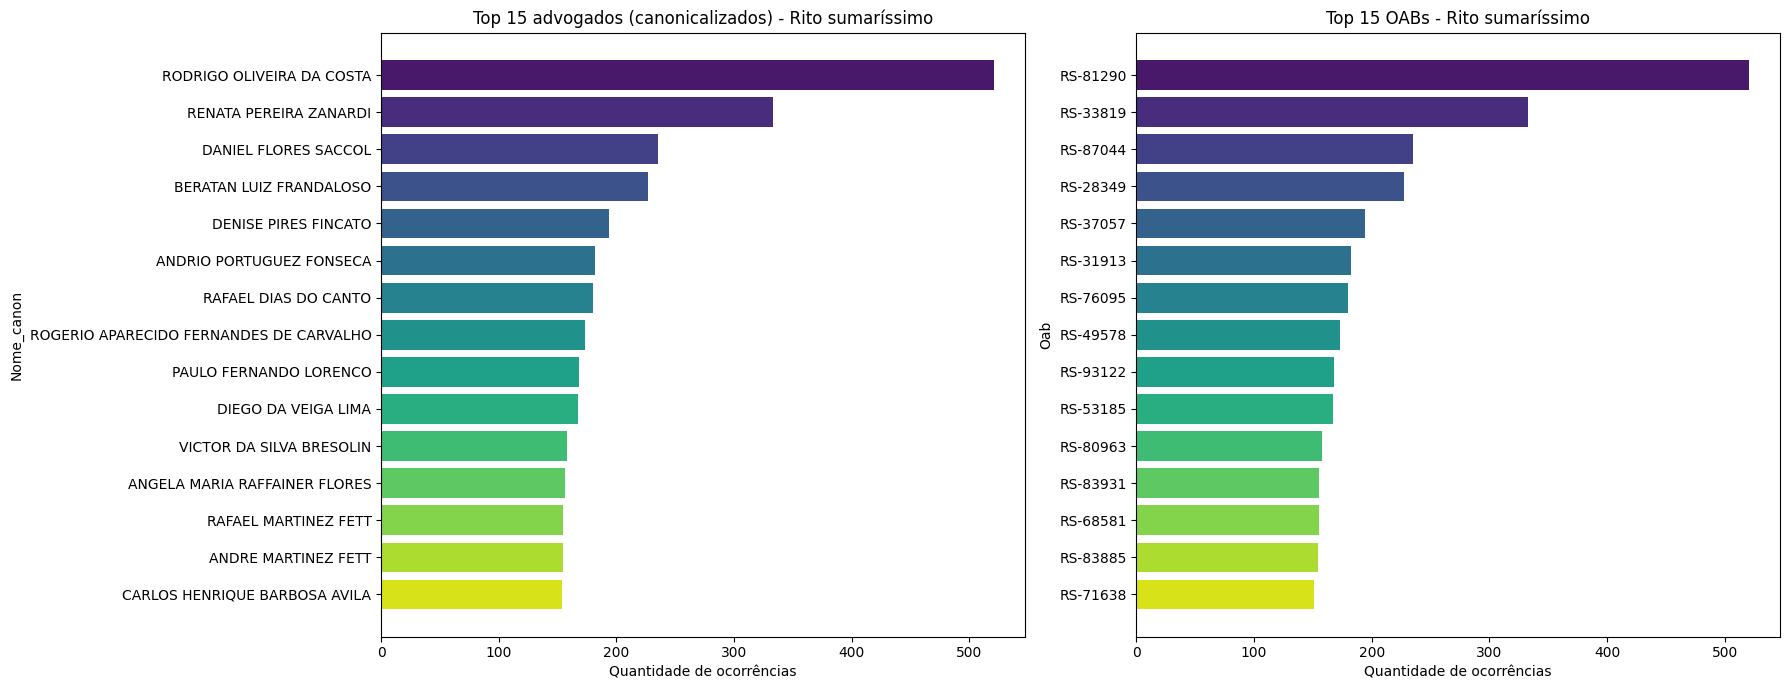

In [11]:
resumo_eda_advogados(df_ord_adv, 'Rito ordinário')
resumo_eda_advogados(df_sum_adv, 'Rito sumaríssimo')

## EDA - Partes polo passivo 

In [15]:
df_ord_passivo = df_ord[df_ord['polo'] == 'Polo Passivo'].copy()
df_sum_passivo = df_sum[df_sum['polo'] == 'Polo Passivo'].copy()


Resumo - Rito ordinário
Partes únicas no polo passivo: 20691
Partes únicas no polo passivo após canonicalização: 20597

Top 10 polos passivos mais comuns:


,quantidade
nome,
WMS SUPERMERCADOS DO BRASIL LTDA.,755
SEARA ALIMENTOS LTDA,468
ESTADO DO RIO GRANDE DO SUL,456
MUNICIPIO DE PORTO ALEGRE,370
MUNICIPIO DE CANOAS,367
MOBRA SERVICOS DE VIGILANCIA LTDA - MASSA FALIDA,347
OI S.A. - EM RECUPERACAO JUDICIAL,338
SEREDE - SERVICOS DE REDE S.A. - EM RECUPERACAO JUDICIAL,334
RGE SUL DISTRIBUIDORA DE ENERGIA S.A.,323



Top 10 polos passivos mais comuns após canonicalização:


,quantidade
nome_canon,
WMS SUPERMERCADOS DO BRASIL LTDA,756
SEARA ALIMENTOS LTDA,468
ESTADO DO RIO GRANDE DO SUL,456
MUNICIPIO DE PORTO ALEGRE,370
MUNICIPIO DE CANOAS,367
MOBRA SERVICOS DE VIGILANCIA LTDA MASSA FALIDA,347
OI S A EM RECUPERACAO JUDICIAL,338
SEREDE SERVICOS DE REDE S A EM RECUPERACAO JUDICIAL,334
RGE SUL DISTRIBUIDORA DE ENERGIA S A,323


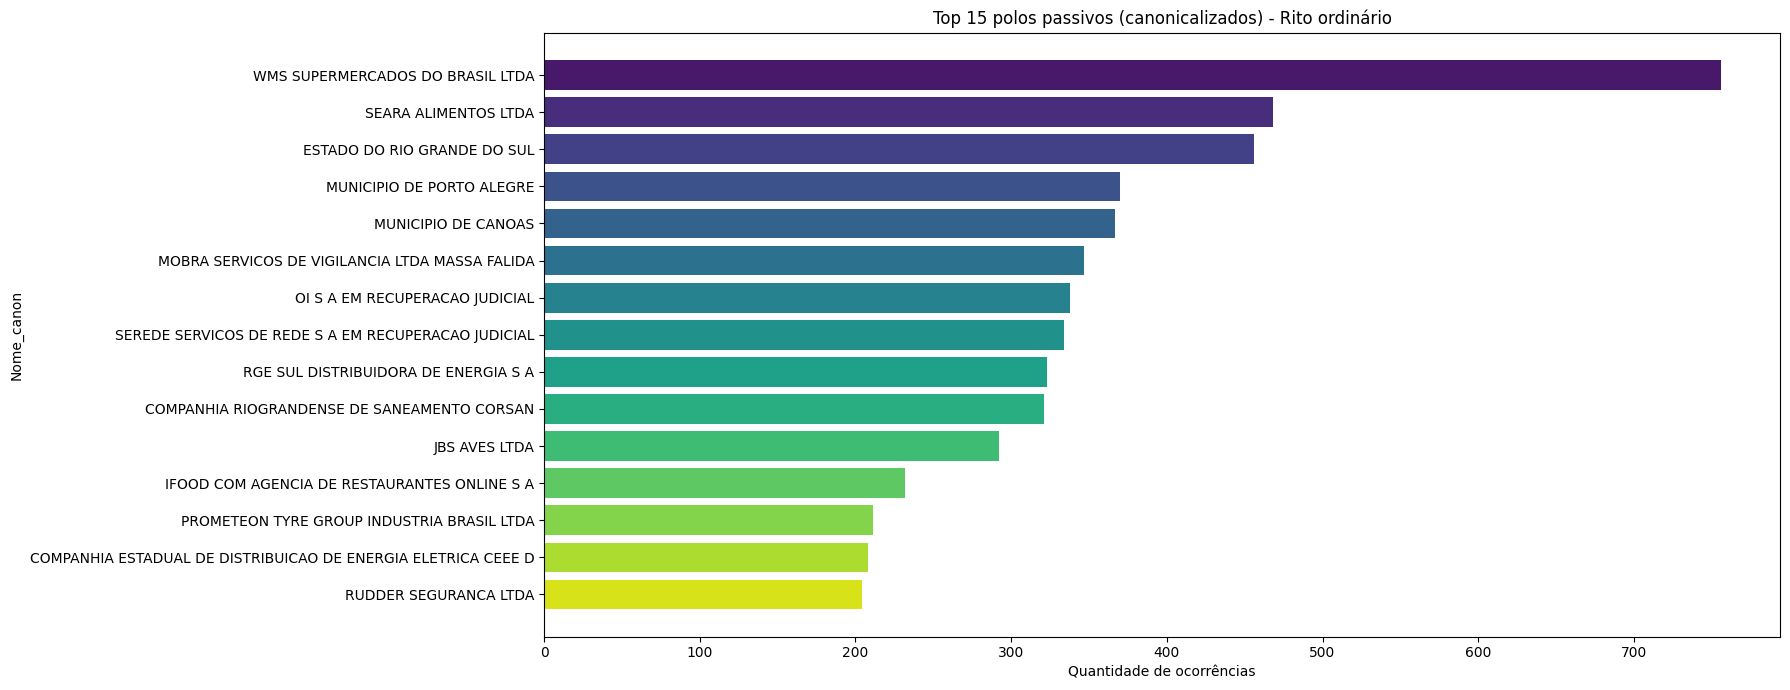


Resumo - Rito sumaríssimo
Partes únicas no polo passivo: 6742
Partes únicas no polo passivo após canonicalização: 6725

Top 10 polos passivos mais comuns:


,quantidade
nome,
ASSOCIACAO HOSPITALAR BENEFICENTE SAO VICENTE DE PAULO,128
JBS AVES LTDA.,123
ARCOS DOURADOS COMERCIO DE ALIMENTOS LTDA,105
COMPANHIA ZAFFARI COMERCIO E INDUSTRIA,94
TOP SERVICE SERVICOS E SISTEMAS S/A,77
SEARA ALIMENTOS LTDA,69
WMS SUPERMERCADOS DO BRASIL LTDA.,61
COOPERATIVA CENTRAL AURORA ALIMENTOS,53
COMERCIAL ZAFFARI LTDA,47



Top 10 polos passivos mais comuns após canonicalização:


,quantidade
nome_canon,
ASSOCIACAO HOSPITALAR BENEFICENTE SAO VICENTE DE PAULO,128
JBS AVES LTDA,123
ARCOS DOURADOS COMERCIO DE ALIMENTOS LTDA,105
COMPANHIA ZAFFARI COMERCIO E INDUSTRIA,94
TOP SERVICE SERVICOS E SISTEMAS S A,77
SEARA ALIMENTOS LTDA,69
WMS SUPERMERCADOS DO BRASIL LTDA,61
COOPERATIVA CENTRAL AURORA ALIMENTOS,53
COMERCIAL ZAFFARI LTDA,47


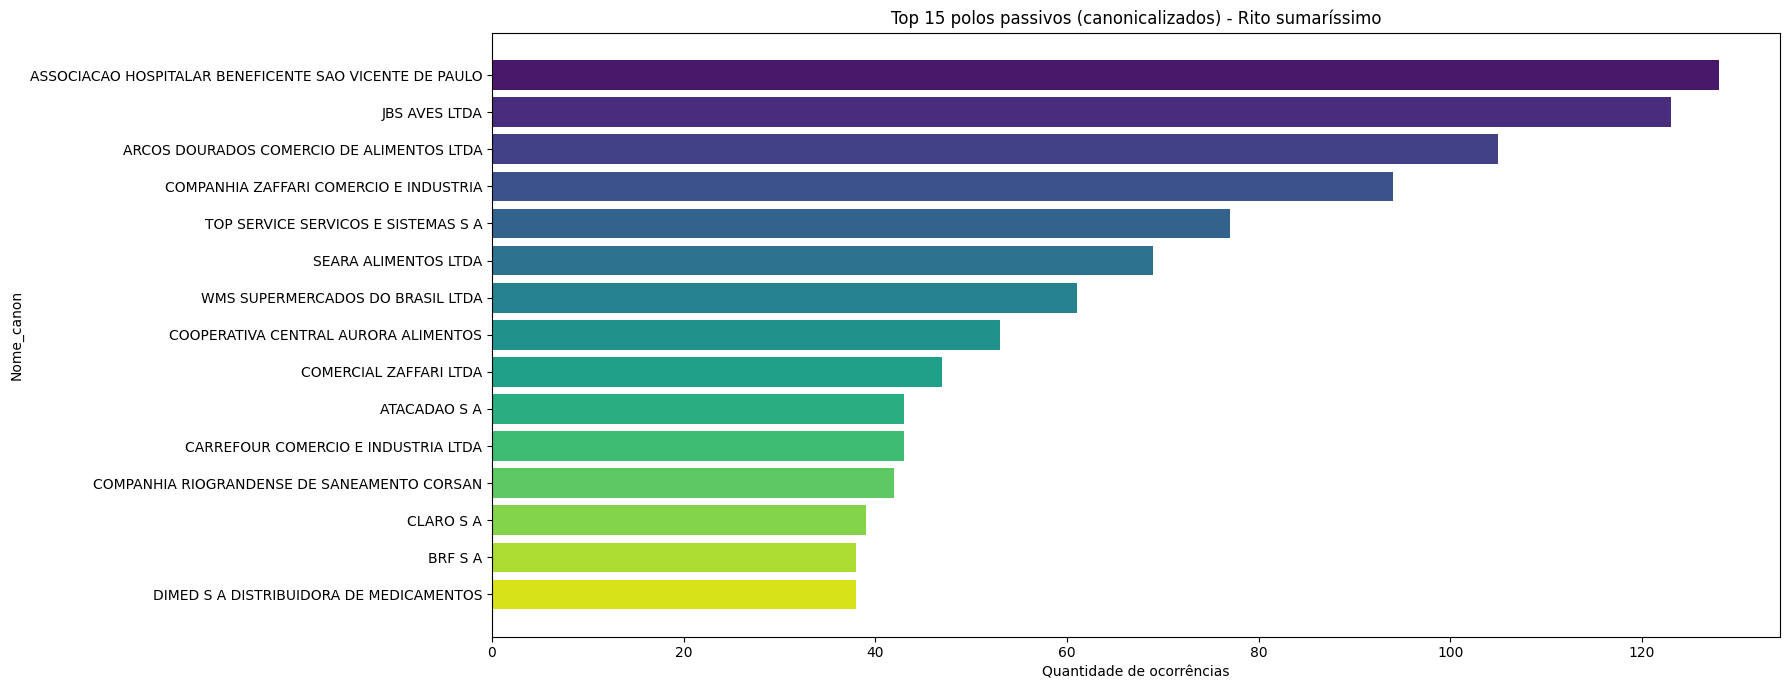

In [16]:
resumo_eda_passivo(df_ord_passivo, 'Rito ordinário')
resumo_eda_passivo(df_sum_passivo, 'Rito sumaríssimo')

## EDA - Partes polo ativo


Resumo - Rito ordinário
Partes únicas no polo ativo: 28984
Partes únicas no polo ativo após canonicalização: 28817

Top 10 polos ativos mais comuns:


,quantidade
nome,
MINISTERIO PUBLICO DO TRABALHO,1615
UNIAO FEDERAL (PGF),512
VANDERLEI ZANON,242
RITA RUTIGLIANO MISSIAGGIA,239
IGOR GUILHERME KUNRATH,219
MUNICIPIO DE CANOAS,212
RENATO BUSATO,203
EVANDRO KREBS GONCALVES,198
OI S.A. - EM RECUPERACAO JUDICIAL,193



Top 10 polos ativos mais comuns após canonicalização:


,quantidade
nome_canon,
MINISTERIO PUBLICO DO TRABALHO,1616
UNIAO FEDERAL PGF,535
VANDERLEI ZANON,242
RITA RUTIGLIANO MISSIAGGIA,239
IGOR GUILHERME KUNRATH,219
MUNICIPIO DE CANOAS,212
RENATO BUSATO,203
EVANDRO KREBS GONCALVES,198
OI S A EM RECUPERACAO JUDICIAL,193


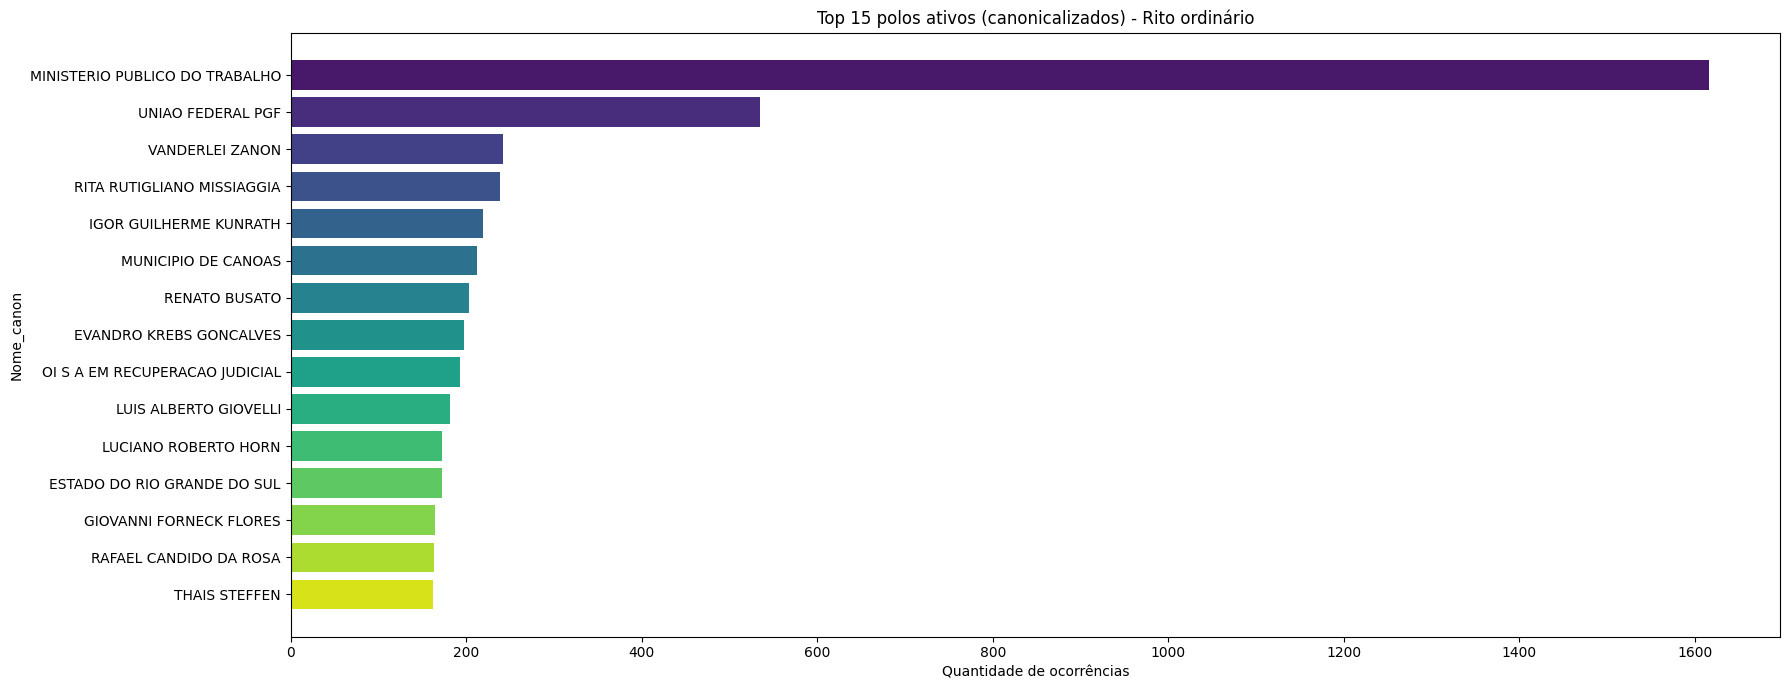


Resumo - Rito sumaríssimo
Partes únicas no polo ativo: 8445
Partes únicas no polo ativo após canonicalização: 8422

Top 10 polos ativos mais comuns:


,quantidade
nome,
UNIAO FEDERAL (PGF),82
CLAY LUIZ PANOSSO,81
ALCIDES FIRPO JUNIOR,76
EVANDRO KREBS GONCALVES,64
MINISTERIO PUBLICO DO TRABALHO,60
RITA RUTIGLIANO MISSIAGGIA,52
ANDRE STEIN LACCHINI,51
GRAZIELI FARIAS PIENIZ,49
VINICIUS ARAUJO SELEME,47



Top 10 polos ativos mais comuns após canonicalização:


,quantidade
nome_canon,
UNIAO FEDERAL PGF,95
CLAY LUIZ PANOSSO,81
ALCIDES FIRPO JUNIOR,76
EVANDRO KREBS GONCALVES,64
MINISTERIO PUBLICO DO TRABALHO,60
RITA RUTIGLIANO MISSIAGGIA,52
ANDRE STEIN LACCHINI,51
GRAZIELI FARIAS PIENIZ,49
VINICIUS ARAUJO SELEME,47


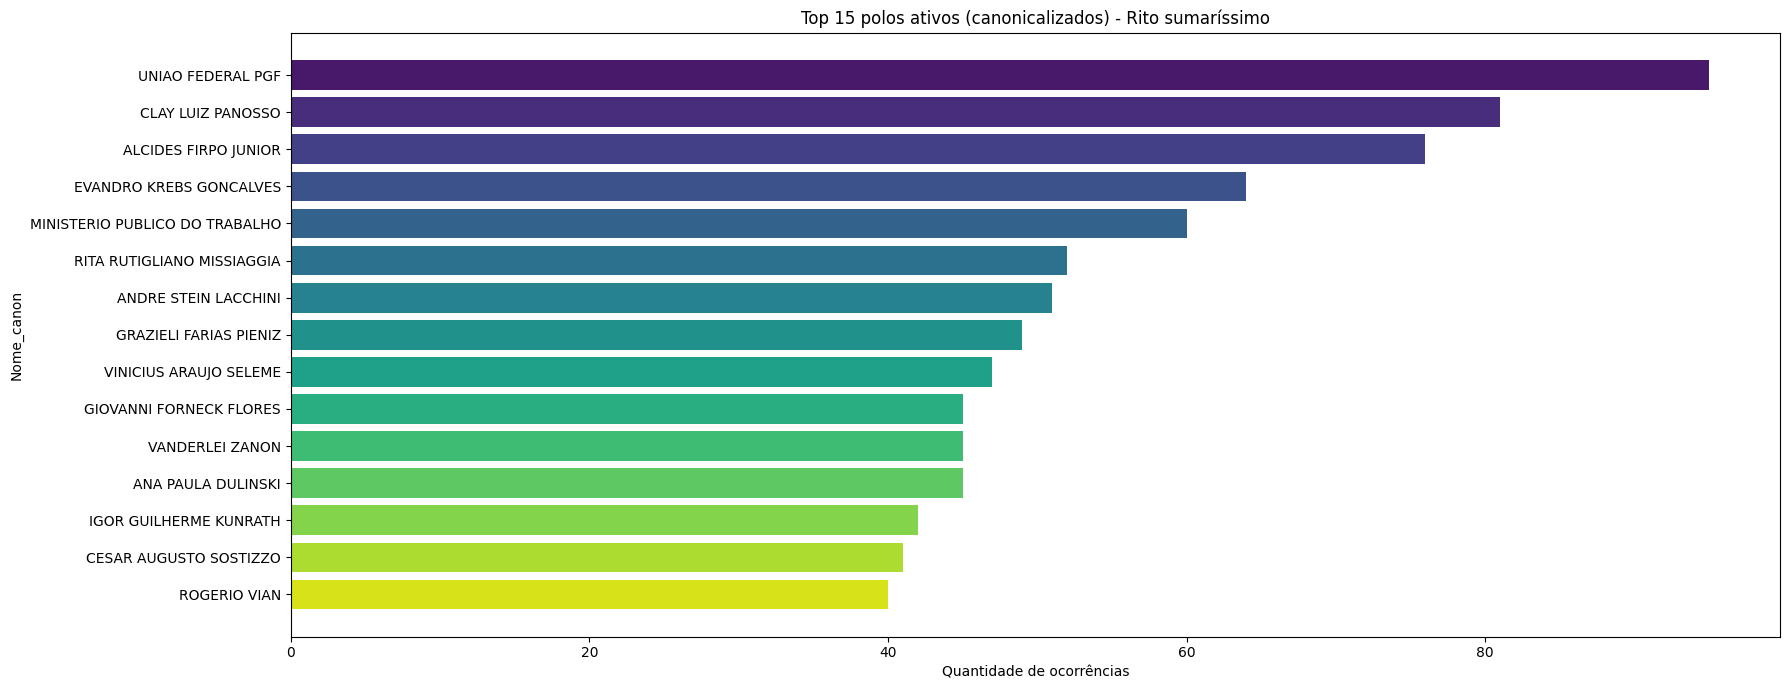

In [17]:
df_ord_ativo = df_ord[df_ord['polo'] == 'Polo Ativo'].copy()
df_sum_ativo = df_sum[df_sum['polo'] == 'Polo Ativo'].copy()
df_ord_ativo['nome_normalizado'] = df_ord_ativo['nome'].apply(normalizar_nome_parte)
df_sum_ativo['nome_normalizado'] = df_sum_ativo['nome'].apply(normalizar_nome_parte)

resumo_eda_ativo(df_ord_ativo, 'Rito ordinário')
resumo_eda_ativo(df_sum_ativo, 'Rito sumaríssimo')

# EDA - Grandes litigantes

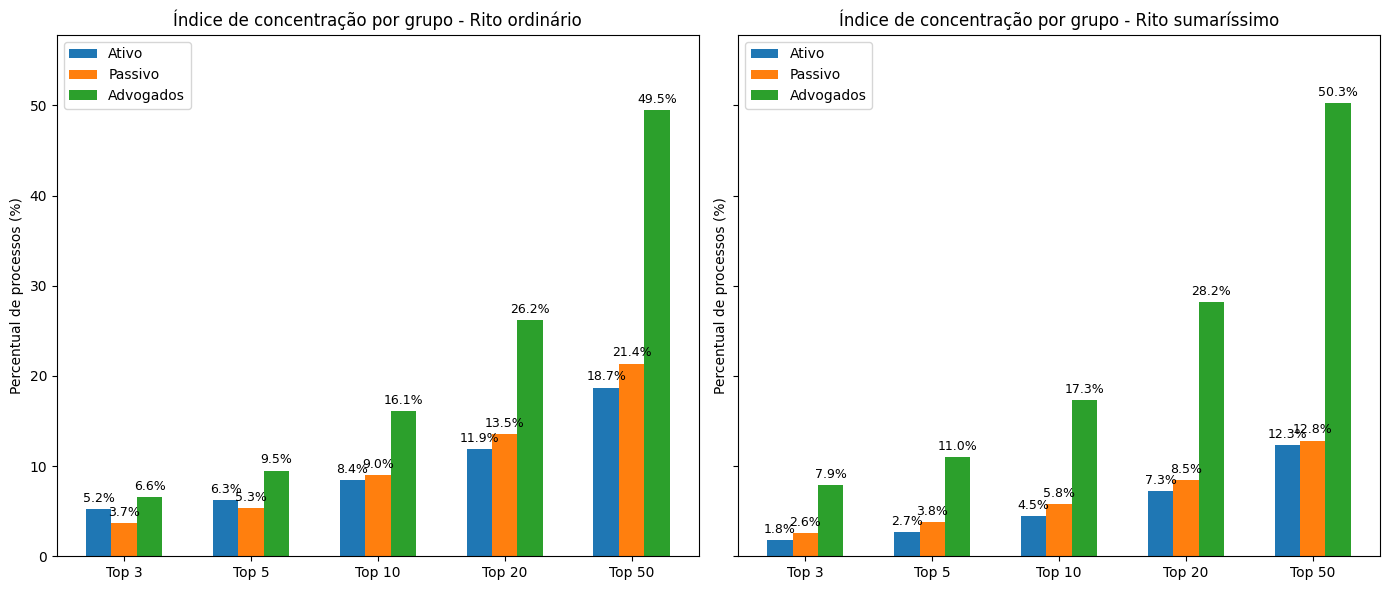

In [21]:
# Cálculo e plot do índice de concentração (Top3/5/10/20/50) usando `numero_processo` único como denominador
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TOP_NS = [3, 5, 10, 20, 50]


def concentration_for_df(group_df, base_df=None, col_candidates=('nome_canon', 'nome_normalizado', 'nome', 'oab')):
    """Calcula a concentração como (soma de processos únicos do Top N nomes) / (total de processos únicos no base_df).

    - group_df: DataFrame contendo as linhas onde o nome aparece (ex: df_ord_adv para advogados)
    - base_df: DataFrame que define o universo de processos para o denominador (ex: df_ord ou df_sum). If None, uses group_df.
    """
    col = next((c for c in col_candidates if c in group_df.columns), None)
    if col is None:
        raise ValueError('Nenhuma coluna de nome encontrada no dataframe')

    # contar processos únicos por nome no grupo
    # garante que usamos a coluna `numero_processo`
    if 'numero_processo' not in group_df.columns:
        raise ValueError('Coluna numero_processo ausente no dataframe')

    counts = group_df.dropna(subset=[col, 'numero_processo']).groupby(col)['numero_processo'].nunique()
    counts = counts.sort_values(ascending=False)

    # total de processos únicos no base (denominador)
    if base_df is None:
        total = group_df['numero_processo'].nunique()
    else:
        total = base_df['numero_processo'].nunique()

    if total == 0:
        return {n: 0.0 for n in TOP_NS}

    return {n: counts.head(n).sum() / total for n in TOP_NS}


# Pairs agora incluem o dataframe base (df_ord / df_sum) e os subsets para cada grupo
pairs = [
    ("Rito ordinário", df_ord, {
        'Ativo': df_ord_ativo,
        'Passivo': df_ord_passivo,
        'Advogados': df_ord_adv
    }),
    ("Rito sumaríssimo", df_sum, {
        'Ativo': df_sum_ativo,
        'Passivo': df_sum_passivo,
        'Advogados': df_sum_adv
    })
]

col_candidates_por_grupo = {
    'Ativo': ('nome_canon', 'nome_normalizado', 'nome'),
    'Passivo': ('nome_canon', 'nome_normalizado', 'nome'),
    'Advogados': ('oab',),
}

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
for ax, (title, base_df, groups) in zip(axes, pairs):
    results = {}
    for name, df in groups.items():
        if df is None:
            results[name] = [np.nan] * len(TOP_NS)
            continue
        res = concentration_for_df(df, base_df=base_df, col_candidates=col_candidates_por_grupo[name])
        results[name] = [res[n] * 100 for n in TOP_NS]  # percent

    x = np.arange(len(TOP_NS))
    width = 0.2
    offsets = np.linspace(-width, width, len(results))

    bars_list = []
    for i, (grp, vals) in enumerate(results.items()):
        bar = ax.bar(x + offsets[i], vals, width=width, label=grp)
        bars_list.append(bar)

    # ajustar limites y para deixar espaço para rótulos
    all_vals = [v for vals in results.values() for v in vals if not np.isnan(v)]
    if all_vals:
        ymax = max(all_vals) * 1.15
        ax.set_ylim(0, ymax)

    # anotar cada barra com percentual formatado
    for bar in bars_list:
        for rect in bar:
            height = rect.get_height()
            if np.isnan(height):
                continue
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f"Top {n}" for n in TOP_NS])
    ax.set_ylabel('Percentual de processos (%)')
    ax.set_title(f'Índice de concentração por grupo - {title}')
    ax.legend()

plt.tight_layout()
plt.show()

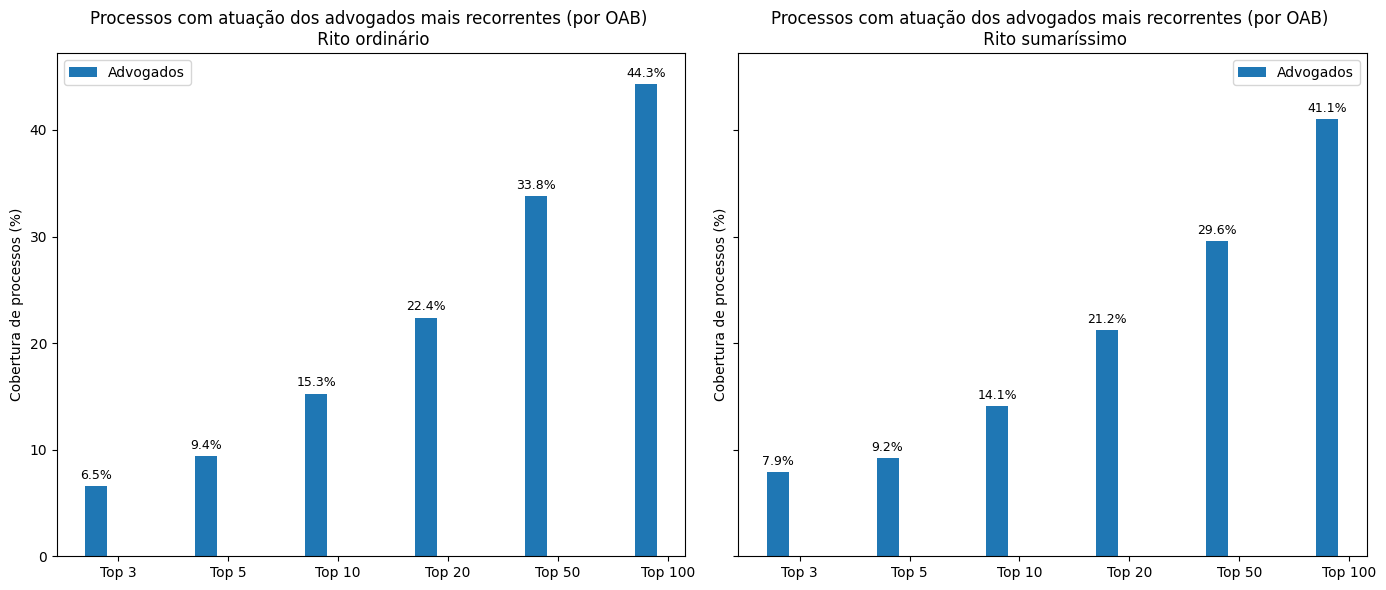

In [32]:
# Gráfico alternativo sem dupla contagem: usa a união dos processos cobertos pelos Top N de cada grupo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

TOP_NS = [3, 5, 10, 20, 50, 100]


def coverage_for_df(group_df, base_df=None, col_candidates=('nome_canon', 'nome_normalizado', 'nome', 'oab')):
    """Calcula cobertura como |união de processos dos Top N valores| / total de processos do base_df.

    Aqui não há dupla contagem: um processo só entra uma vez, mesmo que tenha mais de um valor
    entre os Top N dentro do mesmo grupo.
    """
    col = next((c for c in col_candidates if c in group_df.columns), None)
    if col is None:
        raise ValueError('Nenhuma coluna de nome encontrada no dataframe')

    if 'numero_processo' not in group_df.columns:
        raise ValueError('Coluna numero_processo ausente no dataframe')

    counts = group_df.dropna(subset=[col, 'numero_processo']).groupby(col)['numero_processo'].nunique()
    top_values = counts.sort_values(ascending=False).head(max(TOP_NS)).index

    if base_df is None:
        total = group_df['numero_processo'].nunique()
    else:
        total = base_df['numero_processo'].nunique()

    if total == 0:
        return {n: 0.0 for n in TOP_NS}

    out = {}
    for n in TOP_NS:
        selected = counts.sort_values(ascending=False).head(n).index
        covered = group_df[group_df[col].isin(selected)]['numero_processo'].nunique()
        out[n] = covered / total
    return out


pairs = [
    ("Rito ordinário", df_ord, {
        #'Ativo': df_ord_ativo,
        #'Passivo': df_ord_passivo,
        'Advogados': df_ord_adv,
    }),
    ("Rito sumaríssimo", df_sum, {
        #'Ativo': df_sum_ativo,
        #'Passivo': df_sum_passivo,
        'Advogados': df_sum_adv,
    }),
]

col_candidates_por_grupo = {
    #'Ativo': ('nome_canon', 'nome_normalizado', 'nome'),
    #'Passivo': ('nome_canon', 'nome_normalizado', 'nome'),
    'Advogados': ('oab',),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, (title, base_df, groups) in zip(axes, pairs):
    results = {}
    for name, df in groups.items():
        res = coverage_for_df(df, base_df=base_df, col_candidates=col_candidates_por_grupo[name])
        results[name] = [res[n] * 100 for n in TOP_NS]

    x = np.arange(len(TOP_NS))
    width = 0.2
    offsets = np.linspace(-width, width, len(results))

    bars_list = []
    for i, (grp, vals) in enumerate(results.items()):
        bar = ax.bar(x + offsets[i], vals, width=width, label=grp)
        bars_list.append(bar)

    all_vals = [v for vals in results.values() for v in vals if not np.isnan(v)]
    if all_vals:
        ax.set_ylim(0, max(all_vals) * 1.15)

    for bar in bars_list:
        for rect in bar:
            height = rect.get_height()
            if np.isnan(height):
                continue
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Top {n}' for n in TOP_NS])
    ax.set_ylabel('Cobertura de processos (%)')
    ax.set_title(f'Processos com atuação dos advogados mais recorrentes (por OAB) \n {title}')
    ax.legend()

plt.tight_layout()
plt.show()

# N amostral e dataframes finais

In [29]:
#quantidade total de processos únicos com advogados
print(df_ord_adv['numero_processo'].nunique())
print(df_sum_adv['numero_processo'].nunique())

45344
13737


In [30]:
# os top 100 advogados por OAB (quantidade de processos em que aparecem)
top100oabs_ord = df_ord_adv['oab'].value_counts().head(100).to_frame('quantidade')
top100oabs_sum = df_sum_adv['oab'].value_counts().head(100).to_frame('quantidade')

# os processos que aparecem com esses top 100 advogados
processos_top100oabs_ord = df_ord_adv[df_ord_adv['oab'].isin(top100oabs_ord.index)]['numero_processo'].nunique()
print(processos_top100oabs_ord)

processos_top100oabs_sum = df_sum_adv[df_sum_adv['oab'].isin(top100oabs_sum.index)]['numero_processo'].nunique()
print(processos_top100oabs_sum)

20057
5644


In [37]:
# DF total (ou seja, todos os processos únicos com advogados identificados no ws)
df_ord_adv_unicos = df_ord_adv.drop_duplicates(subset=['numero_processo']).copy()
df_sum_adv_unicos = df_sum_adv.drop_duplicates(subset=['numero_processo']).copy()

df_ord_adv_unicos.to_csv('data/n_amostral/df_trt4_rito_ord_adv_unicos.csv', index=False)
df_sum_adv_unicos.to_csv('data/n_amostral/df_trt4_rito_sum_adv_unicos.csv', index=False)

# ORDINARIO
# processos que têm pelo menos uma OAB do Top 100
processos_top100_ord = set(
    df_ord_adv[df_ord_adv['oab'].isin(top100oabs_ord.index)]['numero_processo']
)

# DF com processos do Top 100, sem repetir processo
df_top100oabs_ord_unicos = (
    df_ord_adv[df_ord_adv['numero_processo'].isin(processos_top100_ord)]
    .drop_duplicates(subset=['numero_processo'])
    .copy()
)
df_top100oabs_ord_unicos.to_csv('data/n_amostral/df_trt4_rito_ord_top100oabs_unicos.csv', index=False)

# DF com processos fora do Top 100, sem repetir processo
df_fora_top100_ord_unicos = (
    df_ord_adv[~df_ord_adv['numero_processo'].isin(processos_top100_ord)]
    .drop_duplicates(subset=['numero_processo'])
    .copy()
)
df_fora_top100_ord_unicos.to_csv('data/n_amostral/df_trt4_rito_ord_fora_top100oabs_unicos.csv', index=False)

#SUMARISSIMO
processos_top100_sum = set(
    df_sum_adv[df_sum_adv['oab'].isin(top100oabs_sum.index)]['numero_processo']
)

df_top100oabs_sum_unicos = (
    df_sum_adv[df_sum_adv['numero_processo'].isin(processos_top100_sum)]
    .drop_duplicates(subset=['numero_processo'])
    .copy()
)
df_top100oabs_sum_unicos.to_csv('data/n_amostral/df_trt4_rito_sum_top100oabs_unicos.csv', index=False)

df_fora_top100_sum_unicos = (
    df_sum_adv[~df_sum_adv['numero_processo'].isin(processos_top100_sum)]
    .drop_duplicates(subset=['numero_processo'])
    .copy()
)
df_fora_top100_sum_unicos.to_csv('data/n_amostral/df_trt4_rito_sum_fora_top100oabs_unicos.csv', index=False)


In [39]:
print('Rito Ordinário - Total de processos únicos com advogados: ', df_ord_adv_unicos['numero_processo'].nunique(), len(df_ord_adv_unicos))
print('Rito Ordinário - Total de processos únicos com advogados fora do Top 100 OABs: ', df_fora_top100_ord_unicos['numero_processo'].nunique(), len(df_fora_top100_ord_unicos))
print('Rito Ordinário - Total de processos únicos com advogados do Top 100 OABs: ', df_top100oabs_ord_unicos['numero_processo'].nunique(), len(df_top100oabs_ord_unicos))

print('Rito Sumaríssimo - Total de processos únicos com advogados: ', df_sum_adv_unicos['numero_processo'].nunique(), len(df_sum_adv_unicos))
print('Rito Sumaríssimo - Total de processos únicos com advogados fora do Top 100 OABs: ', df_fora_top100_sum_unicos['numero_processo'].nunique(), len(df_fora_top100_sum_unicos))
print('Rito Sumaríssimo - Total de processos únicos com advogados do Top 100 OABs: ', df_top100oabs_sum_unicos['numero_processo'].nunique(), len(df_top100oabs_sum_unicos))

Rito Ordinário - Total de processos únicos com advogados:  45344 45344
Rito Ordinário - Total de processos únicos com advogados fora do Top 100 OABs:  25287 25287
Rito Ordinário - Total de processos únicos com advogados do Top 100 OABs:  20057 20057
Rito Sumaríssimo - Total de processos únicos com advogados:  13737 13737
Rito Sumaríssimo - Total de processos únicos com advogados fora do Top 100 OABs:  8093 8093
Rito Sumaríssimo - Total de processos únicos com advogados do Top 100 OABs:  5644 5644


In [42]:
# Amostra estratificada por rito e posição no ranking Top 100 OABs
import numpy as np
import pandas as pd


def calcular_n_amostral_finite_pop(N, margem_erro=0.05, confianca=0.95, proporcao=0.5):
    """Calcula n amostral para população finita.

    - N: tamanho da população
    - margem_erro: erro amostral máximo tolerado
    - confianca: nível de confiança
    - proporcao: p esperado; 0.5 é o caso mais conservador
    """
    if N <= 0:
        return 0

    z_por_confianca = {
        0.80: 1.2816,
        0.90: 1.6449,
        0.95: 1.96,
        0.99: 2.5758,
    }
    z = z_por_confianca.get(confianca, 1.96)
    p = proporcao
    q = 1 - p

    n0 = (z**2 * p * q) / (margem_erro**2)
    n = n0 / (1 + (n0 - 1) / N)
    return int(np.ceil(n))


def amostra_estratificada(df, strata_col, n_total, random_state=42):
    """Sorteia uma amostra estratificada proporcional em strata_col."""
    if n_total <= 0:
        return df.iloc[0:0].copy()

    counts = df[strata_col].value_counts()
    frac = counts / counts.sum()
    n_por_estrato = (frac * n_total).round().astype(int)

    diferenca = n_total - n_por_estrato.sum()
    if diferenca != 0:
        ajustes = counts.sort_values(ascending=False).index.tolist()
        idx = 0
        while diferenca != 0 and ajustes:
            estrato = ajustes[idx % len(ajustes)]
            if diferenca > 0:
                n_por_estrato[estrato] += 1
                diferenca -= 1
            else:
                if n_por_estrato[estrato] > 0:
                    n_por_estrato[estrato] -= 1
                    diferenca += 1
            idx += 1

    amostras = []
    for estrato, n_estrato in n_por_estrato.items():
        if n_estrato <= 0:
            continue
        sub = df[df[strata_col] == estrato]
        n_estrato = min(n_estrato, len(sub))
        amostras.append(sub.sample(n=n_estrato, random_state=random_state))

    if not amostras:
        return df.iloc[0:0].copy()

    return pd.concat(amostras, ignore_index=True)


# Consolida os quatro estratos sem sobreposição
ord_top100 = df_top100oabs_ord_unicos.copy()
ord_fora_top100 = df_fora_top100_ord_unicos.copy()
sum_top100 = df_top100oabs_sum_unicos.copy()
sum_fora_top100 = df_fora_top100_sum_unicos.copy()

ord_top100['estrato'] = 'ordinario_top100'
ord_fora_top100['estrato'] = 'ordinario_fora_top100'
sum_top100['estrato'] = 'sumarissimo_top100'
sum_fora_top100['estrato'] = 'sumarissimo_fora_top100'

base_estratificada = pd.concat(
    [ord_top100, ord_fora_top100, sum_top100, sum_fora_top100],
    ignore_index=True
)

# Escolha o total desejado da amostra.
# Exemplo: calcular um n representativo para toda a base com 95% de confiança e 5% de erro.
N_total = len(base_estratificada)
n_total = calcular_n_amostral_finite_pop(N_total, margem_erro=0.05, confianca=0.95, proporcao=0.5)

amostra_final = amostra_estratificada(base_estratificada, 'estrato', n_total=n_total, random_state=42)

print(f'População total estratificada: {N_total}')
print(f'n amostral total sugerido: {n_total}')
print('\nDistribuição da amostra por estrato:')
print(amostra_final['estrato'].value_counts())

from pathlib import Path

saida_dir = Path('data/n_amostral/sorteados')
saida_dir.mkdir(parents=True, exist_ok=True)
saida_csv = saida_dir / 'amostra_estratificada_processos.csv'
amostra_final.to_csv(saida_csv, index=False)
print(f'Amostra salva em: {saida_csv}')

População total estratificada: 59081
n amostral total sugerido: 382

Distribuição da amostra por estrato:
estrato
ordinario_fora_top100      164
ordinario_top100           130
sumarissimo_fora_top100     52
sumarissimo_top100          36
Name: count, dtype: int64
Amostra salva em: data/n_amostral/sorteados/amostra_estratificada_processos.csv
